(sec:dimer-case3-g2)=
# Second-order coherence


As introduced in {numref}`sec:openqm-qme-cluster`, the two-point second-order coherence function for the dimer is defined as

$$
g^{(2)}(\tau;\mathbf{R}_1,\mathbf{R}_2) 
= \frac{\sum_{ij} \sum_{k\ell} e^{i k_0 \hat{\mathbf{R}}_1\cdot \mathbf{r}_{ij}}e^{i k_0 \hat{\mathbf{R}}_2\cdot \mathbf{r}_{k\ell}} \langle\sigma^{+}_{i}(t) \sigma^{+}_{k}(t+\tau)\sigma^{-}_{\ell}(t+\tau)\sigma^{-}_{j}(t)\rangle_{ss}}{ \left( \sum_{ij} e^{i k_0 \hat{\mathbf{R}}_1\cdot \mathbf{r}_{ij}}\langle\sigma^{+}_{i}(t)\sigma^{-}_{j}(t)\rangle_{ss}\right) \left(\sum_{k\ell} e^{i k_0 \hat{\mathbf{R}}_2\cdot \mathbf{r}_{k\ell}}  \langle \sigma^{+}_{k}(t)\sigma^{-}_{\ell}(t)\rangle_{ss}\right)}
$$

Skornia _et al._{cite:p}`Skornia2001` as able to find an analytical expression, which is a bit too long to be shown here.  For $\tau=0$, it takes a simple form

$$
g^{(2)}(0;\mathbf{R}_1,\mathbf{R}_2) = \frac{s^2 \cos^2(\theta(\mathbf{R}_1)-\theta(\mathbf{R}_2))}{[s+ \cos(\theta(\mathbf{R}_1))][s+ \cos(\theta(\mathbf{R}_2))]}
$$

where $s=2(\Omega/\gamma_0)^2+1$.

## Single point measurement

We begin with a simpler case with a single detector.  $g^{(2)}(\tau;\mathbf{R},\mathbf{R}))$ is computed using the quantum master equation with help of the quantum regression theorem (included in QuTip functions).  The location of the detector is specified by phase parameter $\chi(\mathbf{R})$ and $\phi$. (See {numref}`sec:dimer-case2-g1` for their defintion.)  The results are compared with the analytical expression.  The agreement is perfect. 

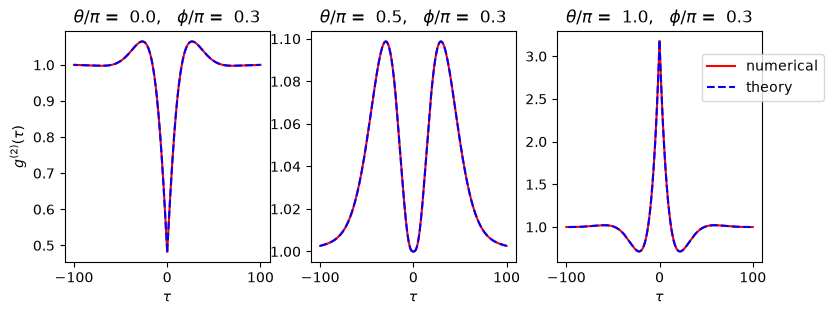

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# basis operators
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# system parameters
gamma0=0.1
Omega = 0.8*gamma0
Delta=0

# position parameter
phi=np.pi/3
ep = np.exp(1j*phi)
em = np.exp(-1j*phi)

# qme
H = 0.5*Delta*(sz[0]+sz[1]) + 0.5*Omega*(ep*sp[0]+em*sm[0]+em*sp[1]+ep*sm[1])
c_ops = [np.sqrt(gamma0)*sm[0], np.sqrt(gamma0)*sm[1]]
rho = steadystate(H,c_ops)

# sampling time
times = np.linspace(0, 1000*gamma0, 1000)

def g2_numerical(phi,theta,times):
    chi = theta - 2*phi
    G2 = np.zeros_like(times, dtype=complex)
    I2 = 0.0
    for i in range(2):
        for j in range(2):
            if (i==j):
                phase1 = 1
            elif i>j:
                phase1 = np.exp(1j*chi)
            else:
                phase1 = np.exp(-1j*chi)
            
            for k in range(2):
                for l in range(2):
                    if (k==l):
                        phase2 = 1
                    elif (k>l):
                        phase2 = np.exp(1j*chi)
                    else:
                        phase2 = np.exp(-1j*chi)
            
                    G2 += phase1*phase2*correlation_3op_1t(H,rho,times,c_ops,sp[i],sp[k]*sm[l],sm[j],solver="me")
                    I2 += phase1*phase2*expect(sp[i]*sm[j],rho)*expect(sp[k]*sm[l],rho)
    return G2/I2

def g2_theory(theta,times):

    s = 2*(Omega/gamma0)**2+1
    v = 0.5*np.sqrt(8*s-9)

    x = 4*np.exp(2*times)*v**2*s*np.sin(theta)*np.sin(theta)
    x += s*(np.exp(times)*v**2*s+(s-1)**2)*np.cos(theta)*np.cos(theta)
    x += - np.exp(3*times/2)*v*s**2 * (2*v*np.cos(v*times)+3*np.sin(v*times))
    x += 2*np.exp(3*times/2)*v*s*(np.cos(theta)+np.cos(theta)) * ( (2*s-3)*np.sin(v*times)-2*v*np.cos(v*times) )
    x += np.exp(times/2)*v* ( 2*np.exp(times)*np.cos(theta)*np.cos(theta)+s*np.sin(theta)*np.sin(theta) ) * ( 2*v*(s-2)*np.cos(v*times)+(5*s-6)*np.sin(v*times) )
    x += 0.25*np.cos(theta)*np.cos(theta)*( ( s*(s*(4*s-33)+64) -36 ) * np.cos(2*v*times) + 2*v*(s-2)*(5*s-6)*np.sin(2*v*times) )
    x = x * np.exp(-3*times)/(4*v**2*(s+np.cos(theta))*(s+np.cos(theta))) + 1
    return x
    
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
theta = 0
plt.title(r"$\theta/\pi$" + f" = {theta/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )
g2_nu = g2_numerical(phi,theta,times)
g2_th = g2_theory(theta,times*gamma0/2)
plt.plot(times,g2_nu.real,color="r")
plt.plot(-times,g2_nu.real,color="r")
plt.plot(times,g2_th,color="b", ls='--')
plt.plot(-times,g2_th,color="b", ls='--')
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")

plt.subplot(1,3,2)
theta = np.pi/2
plt.title(r"$\theta/\pi$" + f" = {theta/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )
g2_nu = g2_numerical(phi,theta,times)
g2_th = g2_theory(theta,times*gamma0/2)
plt.plot(times,g2_nu.real,color="r")
plt.plot(-times,g2_nu.real,color="r")
plt.plot(times,g2_th,color="b", ls='--')
plt.plot(-times,g2_th,color="b", ls='--')
plt.xlabel(r"$\tau$")

plt.subplot(1,3,3)
theta = np.pi
plt.title(r"$\theta/\pi$" + f" = {theta/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )
g2_nu = g2_numerical(phi,theta,times)
g2_th = g2_theory(theta,times*gamma0/2)
plt.plot(times,g2_nu.real,color="r",label="numerical")
plt.plot(-times,g2_nu.real,color="r")
plt.plot(times,g2_th,color="b", ls='--',label="theory")
plt.plot(-times,g2_th,color="b", ls='--')
plt.xlabel(r"$\tau$")
plt.legend(bbox_to_anchor=(1.30, 0.9), borderaxespad=0)
plt.show()


The above results are remarkable. When $\theta(\mathbf{R})=0$, $g^{(2)}(0;\mathbf{R},\mathbf{R}) < 1$ suggesting photon antibunching.  At $\theta(\mathbf{R})=\pi$, $g^{(2)}(0;\mathbf{R},\mathbf{R}) > 1$ indicating photon bunching.  In the middle ($\theta(\mathbf{R})=\pi/2$), $g^{(2)}(0;\mathbf{R},\mathbf{R}) = 1$, which means the full counting statistics should be Poissonian.  In some directions, anti-bunching is observed and in some other directions, bunching is seen.  In the between, we have Poissonian spiking.  

## Second-order fringes

In order to see the above behavior more clearly, the next code plot the nodelay coherence as a function of $\theta$.  We find the fringes of the second-order coherence much like that of the first-order coherence shown above.

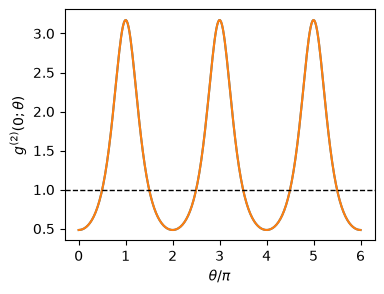

In [2]:
def g2_0_numerical(phi,theta):
    chi = theta - 2*phi
    G2 = 0.0
    I2 = 0.0
    for i in range(2):
        for j in range(2):
            if (i==j):
                phase1 = 1
            elif i>j:
                phase1 = np.exp(1j*chi)
            else:
                phase1 = np.exp(-1j*chi)
            
            for k in range(2):
                for l in range(2):
                    if (k==l):
                        phase2 = 1
                    elif (k>l):
                        phase2 = np.exp(1j*chi)
                    else:
                        phase2 = np.exp(-1j*chi)
            
                    G2 += phase1*phase2*expect(sp[i]*sp[k]*sm[l]*sm[j],rho)
                    I2 += phase1*phase2*expect(sp[i]*sm[j],rho)*expect(sp[k]*sm[l],rho)
    return G2/I2

def g2_0_theory(theta):
    s = 2*(Omega/gamma0)**2+1
    g2 = s**2 * np.cos((theta-theta)/2)**2 /(s+np.cos(theta))/(s+np.cos(theta))
    return g2

theta = np.linspace(0,6*np.pi,300)

x = g2_0_numerical(phi,theta)
y = g2_0_theory(theta)

plt.figure(figsize=(4,3))
plt.plot(theta/np.pi,x.real)
plt.plot(theta/np.pi,y)
plt.ylabel(r"$g^{(2)}(0;\theta)$")
plt.xlabel(r"$\theta/\pi$")
plt.axhline(y=1.0, color='k', linestyle='--', linewidth=1)
plt.show()

## Two-point measurement

A single-point measurement of the second-order coherence showed a remarkable character of the interference.  Now we move on two-point measurement, which shows even more surprising results. While the first detector is fixed at a point, the second detector measure the fringes.  It turns out that the fringe pattern depends on the location of the first detector.

/home/kawai/miniconda3/envs/book/lib/python3.13/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kawai/miniconda3/envs/book/lib/python3.13/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


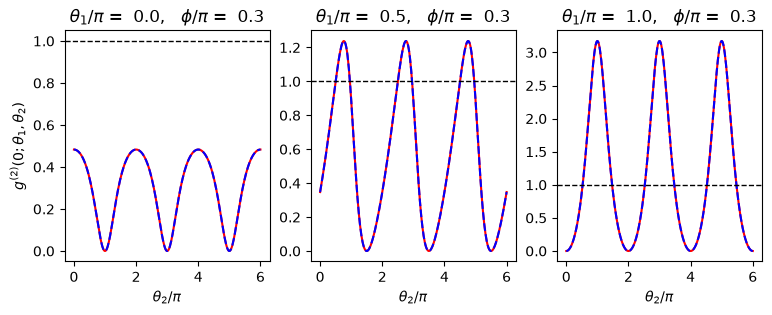

In [3]:
def g2_0_2p_numerical(phi,theta1,tehat2):
    chi1 = theta1 - 2*phi
    chi2 = theta2 - 2*phi
    G2 = 0.0
    I2 = 0.0
    for i in range(2):
        for j in range(2):
            if (i==j):
                phase1 = 1
            elif i>j:
                phase1 = np.exp(1j*chi1)
            else:
                phase1 = np.exp(-1j*chi1)
            
            for k in range(2):
                for l in range(2):
                    if (k==l):
                        phase2 = 1
                    elif (k>l):
                        phase2 = np.exp(1j*chi2)
                    else:
                        phase2 = np.exp(-1j*chi2)
            
                    G2 += phase1*phase2*expect(sp[i]*sp[k]*sm[l]*sm[j],rho)
                    I2 += phase1*phase2*expect(sp[i]*sm[j],rho)*expect(sp[k]*sm[l],rho)
    return G2/I2

def g2_0_2p_theory(theta1,theta2):
    s = 2*(Omega/gamma0)**2+1
    g2 = s**2 * np.cos((theta1-theta2)/2)**2 /(s+np.cos(theta1))/(s+np.cos(theta2))
    return g2


theta2 = np.linspace(0,6*np.pi,300)

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
theta1 = 0
x = g2_0_2p_numerical(phi,theta1,theta2)
y = g2_0_2p_theory(theta1,theta2)
plt.plot(theta2/np.pi,x,color="r")
plt.plot(theta2/np.pi,y,color="b", ls='--')
plt.ylabel(r"$g^{(2)}(0;\theta_1,\theta_2)$")
plt.xlabel(r"$\theta_2/\pi$")
plt.axhline(y=1.0, color='k', linestyle='--', linewidth=1)
plt.title(r"$\theta_1/\pi$" + f" = {theta1/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )

plt.subplot(1,3,2)
theta1 = np.pi/2
x = g2_0_2p_numerical(phi,theta1,theta2)
y = g2_0_2p_theory(theta1,theta2)
plt.plot(theta2/np.pi,x,color="r")
plt.plot(theta2/np.pi,y,color="b", ls='--')
plt.xlabel(r"$\theta_2/\pi$")
plt.axhline(y=1.0, color='k', linestyle='--', linewidth=1)
plt.title(r"$\theta_1/\pi$" + f" = {theta1/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )

plt.subplot(1,3,3)
theta1 = np.pi
x = g2_0_2p_numerical(phi,theta1,theta2)
y = g2_0_2p_theory(theta1,theta2)
plt.plot(theta2/np.pi,x,color="r")
plt.plot(theta2/np.pi,y,color="b", ls='--')
plt.xlabel(r"$\theta_2/\pi$")
plt.axhline(y=1.0, color='k', linestyle='--', linewidth=1)
plt.title(r"$\theta_1/\pi$" + f" = {theta1/np.pi: .1f}" + r",   $\phi/\pi$" + f" = {phi/np.pi: .1f}"  )

plt.show()

When the first detector is at $\theta_1=0$ where $n$ is an integer, the second detector sees only antibunching.  However, when the first detector moves to $\theta_1=\pi/2$, the second detector begins to see bunching in certain places. When the first detector further moves to $\theta_1=\pi/2$, the amplitude of the fringes gets bigger and strong bunching can be seen.  In terstingly, the phase of the fringes flipped as the first detector moved from $\theta_1=0$ to $\theta_1=\pi/2$.  The second detector initially observes a perfect antibunching ($g^{(2)}(0)=0$) at $\theta_2 = \pi$. As the first detector moves, the second detector observes a very strong bunching at the same place $\theta_2 = \pi$.  Hence, the first detector acts as a switch to flip between bunching/antibunching.

When the first detector detect a photon, the state of QDs collapse to a state, which influences the photon detection at the second detector.  If there were no first detector, the collapse does not take places and we obtain the results of the single detector discussed above.  We want to know to which state the wavefunction collapses by the first detector.  Quantum trujectory is useful for that. 